random
EVIDENCE-balanced_by_score
BELIEF-balanced_by_score


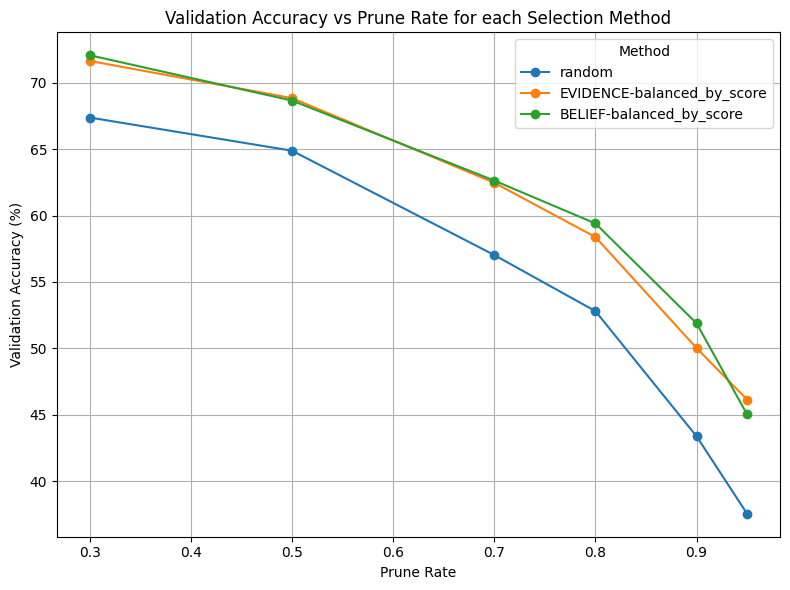

In [5]:
import re
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

# Sample experiment log lines as a multi-line string
log_data = """
MODEL:resnet18_CIFAR10_E1_1 , Train Loss: 0.0811, Train Accuracy: 91.66, Validation Loss: 0.8463, Validation Accuracy: 75.14%
MODEL:resnet18-CIFAR10-random-0.3-1 , Train Loss: 0.0564, Train Accuracy: 75.65, Validation Loss: 0.9264, Validation Accuracy: 68.72%
MODEL:resnet18-CIFAR10-random-0.5-1 , Train Loss: 0.1786, Train Accuracy: 73.49, Validation Loss: 1.1225, Validation Accuracy: 62.73%
MODEL:resnet18-CIFAR10-random-0.7-1 , Train Loss: 0.1247, Train Accuracy: 69.27, Validation Loss: 1.3100, Validation Accuracy: 57.32%
MODEL:resnet18-CIFAR10-random-0.8-1 , Train Loss: 0.3453, Train Accuracy: 66.27, Validation Loss: 1.4922, Validation Accuracy: 50.05%
MODEL:resnet18-CIFAR10-random-0.9-1 , Train Loss: 1.0467, Train Accuracy: 62.89, Validation Loss: 1.6038, Validation Accuracy: 46.79%
MODEL:resnet18-CIFAR10-random-0.95-1 , Train Loss: 1.1503, Train Accuracy: 58.12, Validation Loss: 2.0126, Validation Accuracy: 38.44%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.3-1 , Train Loss: 0.0663, Train Accuracy: 92.00, Validation Loss: 0.8663, Validation Accuracy: 71.14%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.5-1 , Train Loss: 0.1789, Train Accuracy: 91.94, Validation Loss: 0.8835, Validation Accuracy: 67.07%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.7-1 , Train Loss: 0.1138, Train Accuracy: 92.69, Validation Loss: 0.9159, Validation Accuracy: 60.43%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.8-1 , Train Loss: 0.2698, Train Accuracy: 93.86, Validation Loss: 0.9311, Validation Accuracy: 57.23%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.9-1 , Train Loss: 0.7578, Train Accuracy: 94.04, Validation Loss: 0.9640, Validation Accuracy: 50.63%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.95-1 , Train Loss: 0.7676, Train Accuracy: 91.68, Validation Loss: 0.9799, Validation Accuracy: 44.57%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.3-1 , Train Loss: 0.0659, Train Accuracy: 92.19, Validation Loss: 0.8630, Validation Accuracy: 72.23%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.5-1 , Train Loss: 0.1784, Train Accuracy: 92.47, Validation Loss: 0.8849, Validation Accuracy: 68.26%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.7-1 , Train Loss: 0.1147, Train Accuracy: 92.08, Validation Loss: 0.9012, Validation Accuracy: 63.39%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.8-1 , Train Loss: 0.2707, Train Accuracy: 93.18, Validation Loss: 0.9236, Validation Accuracy: 58.65%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.9-1 , Train Loss: 0.7578, Train Accuracy: 93.63, Validation Loss: 0.9441, Validation Accuracy: 53.45%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.95-1 , Train Loss: 0.7555, Train Accuracy: 94.28, Validation Loss: 0.9715, Validation Accuracy: 43.98%
MODEL:resnet18_CIFAR10_E1_2 , Train Loss: 0.0816, Train Accuracy: 91.32, Validation Loss: 0.8500, Validation Accuracy: 74.32%
MODEL:resnet18-CIFAR10-random-0.3-2 , Train Loss: 0.0581, Train Accuracy: 75.47, Validation Loss: 0.9475, Validation Accuracy: 68.16%
MODEL:resnet18-CIFAR10-random-0.5-2 , Train Loss: 0.1757, Train Accuracy: 72.80, Validation Loss: 1.0046, Validation Accuracy: 66.65%
MODEL:resnet18-CIFAR10-random-0.7-2 , Train Loss: 0.1209, Train Accuracy: 70.63, Validation Loss: 1.2702, Validation Accuracy: 57.27%
MODEL:resnet18-CIFAR10-random-0.8-2 , Train Loss: 0.3295, Train Accuracy: 66.58, Validation Loss: 1.3731, Validation Accuracy: 54.58%
MODEL:resnet18-CIFAR10-random-0.9-2 , Train Loss: 1.0535, Train Accuracy: 62.45, Validation Loss: 1.8668, Validation Accuracy: 39.89%
MODEL:resnet18-CIFAR10-random-0.95-2 , Train Loss: 1.0368, Train Accuracy: 60.40, Validation Loss: 2.4919, Validation Accuracy: 32.68%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.3-2 , Train Loss: 0.0663, Train Accuracy: 91.67, Validation Loss: 0.8628, Validation Accuracy: 72.02%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.5-2 , Train Loss: 0.1790, Train Accuracy: 92.02, Validation Loss: 0.8744, Validation Accuracy: 69.90%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.7-2 , Train Loss: 0.1137, Train Accuracy: 92.55, Validation Loss: 0.9022, Validation Accuracy: 63.62%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.8-2 , Train Loss: 0.2687, Train Accuracy: 93.44, Validation Loss: 0.9393, Validation Accuracy: 56.67%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.9-2 , Train Loss: 0.7529, Train Accuracy: 94.82, Validation Loss: 0.9677, Validation Accuracy: 49.57%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.95-2 , Train Loss: 0.7578, Train Accuracy: 93.68, Validation Loss: 0.9711, Validation Accuracy: 45.65%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.3-2 , Train Loss: 0.0661, Train Accuracy: 92.20, Validation Loss: 0.8565, Validation Accuracy: 73.70%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.5-2 , Train Loss: 0.1785, Train Accuracy: 92.26, Validation Loss: 0.8684, Validation Accuracy: 70.79%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.7-2 , Train Loss: 0.1136, Train Accuracy: 92.73, Validation Loss: 0.9016, Validation Accuracy: 63.87%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.8-2 , Train Loss: 0.2714, Train Accuracy: 93.25, Validation Loss: 0.9203, Validation Accuracy: 59.74%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.9-2 , Train Loss: 0.7555, Train Accuracy: 94.31, Validation Loss: 0.9708, Validation Accuracy: 49.46%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.95-2 , Train Loss: 0.7604, Train Accuracy: 93.52, Validation Loss: 0.9699, Validation Accuracy: 46.44%
MODEL:resnet18_CIFAR10_E1_3 , Train Loss: 0.0809, Train Accuracy: 91.40, Validation Loss: 0.8542, Validation Accuracy: 73.86%
MODEL:resnet18-CIFAR10-random-0.3-3 , Train Loss: 0.0576, Train Accuracy: 76.35, Validation Loss: 1.0523, Validation Accuracy: 64.21%
MODEL:resnet18-CIFAR10-random-0.5-3 , Train Loss: 0.1755, Train Accuracy: 73.63, Validation Loss: 0.9774, Validation Accuracy: 66.70%
MODEL:resnet18-CIFAR10-random-0.7-3 , Train Loss: 0.1266, Train Accuracy: 69.99, Validation Loss: 1.4176, Validation Accuracy: 52.32%
MODEL:resnet18-CIFAR10-random-0.8-3 , Train Loss: 0.3246, Train Accuracy: 67.52, Validation Loss: 1.3591, Validation Accuracy: 54.27%
MODEL:resnet18-CIFAR10-random-0.9-3 , Train Loss: 1.0537, Train Accuracy: 62.17, Validation Loss: 1.8326, Validation Accuracy: 42.17%
MODEL:resnet18-CIFAR10-random-0.95-3 , Train Loss: 0.8768, Train Accuracy: 67.64, Validation Loss: 2.5274, Validation Accuracy: 34.16%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.3-3 , Train Loss: 0.0659, Train Accuracy: 92.06, Validation Loss: 0.8659, Validation Accuracy: 71.44%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.5-3 , Train Loss: 0.1798, Train Accuracy: 92.15, Validation Loss: 0.8859, Validation Accuracy: 67.51%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.7-3 , Train Loss: 0.1148, Train Accuracy: 92.46, Validation Loss: 0.9059, Validation Accuracy: 62.15%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.8-3 , Train Loss: 0.2716, Train Accuracy: 93.15, Validation Loss: 0.9418, Validation Accuracy: 54.99%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.9-3 , Train Loss: 0.7578, Train Accuracy: 93.63, Validation Loss: 0.9842, Validation Accuracy: 45.68%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.95-3 , Train Loss: 0.7645, Train Accuracy: 92.16, Validation Loss: 0.9753, Validation Accuracy: 45.77%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.3-3 , Train Loss: 0.0660, Train Accuracy: 92.14, Validation Loss: 0.8746, Validation Accuracy: 68.77%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.5-3 , Train Loss: 0.1787, Train Accuracy: 92.09, Validation Loss: 0.8930, Validation Accuracy: 65.96%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.7-3 , Train Loss: 0.1148, Train Accuracy: 92.50, Validation Loss: 0.9334, Validation Accuracy: 57.08%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.8-3 , Train Loss: 0.2713, Train Accuracy: 93.30, Validation Loss: 0.9285, Validation Accuracy: 58.55%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.9-3 , Train Loss: 0.7543, Train Accuracy: 94.63, Validation Loss: 0.9592, Validation Accuracy: 50.66%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.95-3 , Train Loss: 0.7594, Train Accuracy: 94.32, Validation Loss: 0.9805, Validation Accuracy: 43.21%
MODEL:resnet18_CIFAR10_E1_1 , Train Loss: 0.0792, Train Accuracy: 95.22, Validation Loss: 0.8548, Validation Accuracy: 75.32%
MODEL:resnet18-CIFAR10-random-0.3-1 , Train Loss: 0.0562, Train Accuracy: 75.48, Validation Loss: 1.0313, Validation Accuracy: 65.63%
MODEL:resnet18-CIFAR10-random-0.5-1 , Train Loss: 0.1807, Train Accuracy: 73.50, Validation Loss: 1.0918, Validation Accuracy: 62.63%
MODEL:resnet18-CIFAR10-random-0.7-1 , Train Loss: 0.1243, Train Accuracy: 69.01, Validation Loss: 1.1328, Validation Accuracy: 61.16%
MODEL:resnet18-CIFAR10-random-0.8-1 , Train Loss: 0.3309, Train Accuracy: 67.49, Validation Loss: 1.4502, Validation Accuracy: 52.62%
MODEL:resnet18-CIFAR10-random-0.9-1 , Train Loss: 1.0404, Train Accuracy: 61.33, Validation Loss: 1.5566, Validation Accuracy: 47.18%
MODEL:resnet18-CIFAR10-random-0.95-1 , Train Loss: 1.2604, Train Accuracy: 54.64, Validation Loss: 1.6683, Validation Accuracy: 41.61%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.3-1 , Train Loss: 0.0645, Train Accuracy: 95.70, Validation Loss: 0.8744, Validation Accuracy: 71.64%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.5-1 , Train Loss: 0.1744, Train Accuracy: 96.46, Validation Loss: 0.8921, Validation Accuracy: 68.57%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.7-1 , Train Loss: 0.1110, Train Accuracy: 96.33, Validation Loss: 0.9141, Validation Accuracy: 63.76%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.8-1 , Train Loss: 0.2616, Train Accuracy: 97.42, Validation Loss: 0.9355, Validation Accuracy: 60.33%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.9-1 , Train Loss: 0.7407, Train Accuracy: 97.27, Validation Loss: 0.9731, Validation Accuracy: 50.27%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.95-1 , Train Loss: 0.7370, Train Accuracy: 98.20, Validation Loss: 0.9806, Validation Accuracy: 48.05%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.3-1 , Train Loss: 0.0646, Train Accuracy: 95.92, Validation Loss: 0.8668, Validation Accuracy: 72.96%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.5-1 , Train Loss: 0.1734, Train Accuracy: 96.58, Validation Loss: 0.8824, Validation Accuracy: 70.26%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.7-1 , Train Loss: 0.1111, Train Accuracy: 96.90, Validation Loss: 0.9088, Validation Accuracy: 64.41%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.8-1 , Train Loss: 0.2626, Train Accuracy: 97.17, Validation Loss: 0.9315, Validation Accuracy: 60.79%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.9-1 , Train Loss: 0.7423, Train Accuracy: 96.78, Validation Loss: 0.9726, Validation Accuracy: 51.44%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.95-1 , Train Loss: 0.7466, Train Accuracy: 96.84, Validation Loss: 0.9877, Validation Accuracy: 45.71%
MODEL:resnet18_CIFAR10_E1_2 , Train Loss: 0.0793, Train Accuracy: 95.23, Validation Loss: 0.8549, Validation Accuracy: 74.69%
MODEL:resnet18-CIFAR10-random-0.3-2 , Train Loss: 0.0574, Train Accuracy: 75.74, Validation Loss: 0.8242, Validation Accuracy: 71.71%
MODEL:resnet18-CIFAR10-random-0.5-2 , Train Loss: 0.1758, Train Accuracy: 72.96, Validation Loss: 0.9892, Validation Accuracy: 66.12%
MODEL:resnet18-CIFAR10-random-0.7-2 , Train Loss: 0.1146, Train Accuracy: 69.87, Validation Loss: 1.3302, Validation Accuracy: 55.44%
MODEL:resnet18-CIFAR10-random-0.8-2 , Train Loss: 0.3503, Train Accuracy: 65.64, Validation Loss: 1.2999, Validation Accuracy: 54.57%
MODEL:resnet18-CIFAR10-random-0.9-2 , Train Loss: 1.0278, Train Accuracy: 62.23, Validation Loss: 1.8200, Validation Accuracy: 42.53%
MODEL:resnet18-CIFAR10-random-0.95-2 , Train Loss: 1.3688, Train Accuracy: 49.44, Validation Loss: 1.7233, Validation Accuracy: 41.54%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.3-2 , Train Loss: 0.0646, Train Accuracy: 95.81, Validation Loss: 0.8671, Validation Accuracy: 72.79%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.5-2 , Train Loss: 0.1735, Train Accuracy: 96.48, Validation Loss: 0.8908, Validation Accuracy: 69.21%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.7-2 , Train Loss: 0.1118, Train Accuracy: 96.80, Validation Loss: 0.9129, Validation Accuracy: 64.03%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.8-2 , Train Loss: 0.2640, Train Accuracy: 97.13, Validation Loss: 0.9356, Validation Accuracy: 59.20%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.9-2 , Train Loss: 0.7356, Train Accuracy: 98.43, Validation Loss: 0.9705, Validation Accuracy: 51.85%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.95-2 , Train Loss: 0.7482, Train Accuracy: 95.88, Validation Loss: 0.9873, Validation Accuracy: 45.89%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.3-2 , Train Loss: 0.0644, Train Accuracy: 95.85, Validation Loss: 0.8702, Validation Accuracy: 72.56%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.5-2 , Train Loss: 0.1744, Train Accuracy: 96.40, Validation Loss: 0.8921, Validation Accuracy: 68.19%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.7-2 , Train Loss: 0.1113, Train Accuracy: 96.25, Validation Loss: 0.9214, Validation Accuracy: 62.27%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.8-2 , Train Loss: 0.2626, Train Accuracy: 97.15, Validation Loss: 0.9269, Validation Accuracy: 61.44%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.9-2 , Train Loss: 0.7370, Train Accuracy: 97.76, Validation Loss: 0.9604, Validation Accuracy: 53.92%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.95-2 , Train Loss: 0.7448, Train Accuracy: 96.72, Validation Loss: 0.9868, Validation Accuracy: 46.10%
MODEL:resnet18_CIFAR10_E1_3 , Train Loss: 0.0794, Train Accuracy: 95.06, Validation Loss: 0.8523, Validation Accuracy: 75.66%
MODEL:resnet18-CIFAR10-random-0.3-3 , Train Loss: 0.0584, Train Accuracy: 75.67, Validation Loss: 1.0109, Validation Accuracy: 65.85%
MODEL:resnet18-CIFAR10-random-0.5-3 , Train Loss: 0.1805, Train Accuracy: 73.62, Validation Loss: 1.0462, Validation Accuracy: 64.47%
MODEL:resnet18-CIFAR10-random-0.7-3 , Train Loss: 0.1268, Train Accuracy: 69.81, Validation Loss: 1.2340, Validation Accuracy: 58.65%
MODEL:resnet18-CIFAR10-random-0.8-3 , Train Loss: 0.3286, Train Accuracy: 66.58, Validation Loss: 1.5128, Validation Accuracy: 50.73%
MODEL:resnet18-CIFAR10-random-0.9-3 , Train Loss: 1.0442, Train Accuracy: 62.23, Validation Loss: 1.7021, Validation Accuracy: 41.71%
MODEL:resnet18-CIFAR10-random-0.95-3 , Train Loss: 1.1751, Train Accuracy: 57.44, Validation Loss: 2.0470, Validation Accuracy: 36.84%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.3-3 , Train Loss: 0.0649, Train Accuracy: 96.09, Validation Loss: 0.8782, Validation Accuracy: 70.83%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.5-3 , Train Loss: 0.1738, Train Accuracy: 96.09, Validation Loss: 0.8837, Validation Accuracy: 70.80%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.7-3 , Train Loss: 0.1109, Train Accuracy: 96.39, Validation Loss: 0.9291, Validation Accuracy: 60.82%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.8-3 , Train Loss: 0.2631, Train Accuracy: 97.16, Validation Loss: 0.9223, Validation Accuracy: 61.87%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.9-3 , Train Loss: 0.7407, Train Accuracy: 97.14, Validation Loss: 0.9669, Validation Accuracy: 52.13%
MODEL:resnet18-EvidenceLoss-CIFAR10-EVIDENCE-balanced_by_score-0.95-3 , Train Loss: 0.7345, Train Accuracy: 99.00, Validation Loss: 0.9795, Validation Accuracy: 46.90%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.3-3 , Train Loss: 0.0645, Train Accuracy: 96.06, Validation Loss: 0.8725, Validation Accuracy: 72.20%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.5-3 , Train Loss: 0.1743, Train Accuracy: 96.11, Validation Loss: 0.8954, Validation Accuracy: 68.49%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.7-3 , Train Loss: 0.1111, Train Accuracy: 96.58, Validation Loss: 0.9086, Validation Accuracy: 64.78%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.8-3 , Train Loss: 0.2644, Train Accuracy: 97.08, Validation Loss: 0.9463, Validation Accuracy: 57.26%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.9-3 , Train Loss: 0.7420, Train Accuracy: 96.82, Validation Loss: 0.9680, Validation Accuracy: 52.39%
MODEL:resnet18-EvidenceLoss-CIFAR10-BELIEF-balanced_by_score-0.95-3 , Train Loss: 0.7527, Train Accuracy: 95.68, Validation Loss: 0.9986, Validation Accuracy: 44.69%
"""

# Regular expression patterns.
# This pattern expects lines like: "MODEL:resnet18-CIFAR10-random-0.3-1 ..."
# It captures: method, prune rate and repetition.
pattern = re.compile(
    r'MODEL:resnet18(?:[-_]EvidenceLoss)?[-_]CIFAR10[-_](.+?)(?=-([\d.]+)-(\d+))'
)
# Pattern to extract validation accuracy
val_acc_pattern = re.compile(r"Validation Accuracy:\s*([\d.]+)%")

# Dictionary to store results: { method: { prune_rate: [val_acc, ...], ... }, ... }
results = defaultdict(lambda: defaultdict(list))

# Process each line
for line in log_data.splitlines():
    # Skip empty lines
    if not line.strip():
        continue
    # If it doesn't match our expected pattern, skip it
    match = pattern.search(line)
    if not match:
        continue
    method, prune_rate_str, repetition = match.groups()
    prune_rate = float(prune_rate_str)
    
    # Extract the Validation Accuracy value.
    acc_match = val_acc_pattern.search(line)
    if acc_match:
        val_acc = float(acc_match.group(1))
    else:
        continue  # skip if validation accuracy is not found
    
    # Store the value
    results[method][prune_rate].append(val_acc)

# Average the validation accuracy for each method-prune rate grouping.
avg_results = {}
for method, pr_data in results.items():
    print(method)
    avg_results[method] = {}
    for p_rate, accs in pr_data.items():
        avg_results[method][p_rate] = np.mean(accs)

# Plotting
plt.figure(figsize=(8, 6))

for method, pr_data in avg_results.items():
    # Get sorted lists for x and y
    sorted_items = sorted(pr_data.items())
    x_vals = [item[0] for item in sorted_items]
    y_vals = [item[1] for item in sorted_items]
    plt.plot(x_vals, y_vals, marker='o', label=method)

plt.xlabel("Prune Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy vs Prune Rate for each Selection Method")
plt.legend(title="Method")
plt.grid(True)
plt.tight_layout()
plt.show()
